# AstroCLIP Teaching Exercises

Complete the TODOs below to reproduce the full pipeline.

0## 0. Environment Setup
Import the libraries, set `ASTROCLIP_ROOT`, and detect the device.

In [16]:
# Imports and environment setup
import os
from pathlib import Path
import math

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from torch.utils.data import Dataset, DataLoader, TensorDataset
from datasets import load_from_disk
import umap

from astroclip.data.datamodule import AstroClipCollator
from teaching_scripts.data_utils import (
    build_image_dataloader,
    build_spectrum_dataloader,
    build_multimodal_dataloader,
)
from teaching_scripts.models import ImageAutoencoder, SpectrumAutoencoder, SmallCLIPModel

ASTROCLIP_ROOT = Path(os.environ.get("ASTROCLIP_ROOT", "/Users/marchuertascompany/Documents/teaching/2025_astroinfo/data")).resolve()
ASTROCLIP_ROOT.mkdir(parents=True, exist_ok=True)

subset_path = ASTROCLIP_ROOT #/ "astroclip_subset_tiny"
if not subset_path.exists():
    raise FileNotFoundError(f"Dataset not found at {subset_path}. Prepare the subset first.")

ds = load_from_disk(subset_path)
print({split: len(ds[split]) for split in ds})

collator = AstroClipCollator(center_crop=144)

image_train_loader = build_image_dataloader(ds["train"], batch_size=128, shuffle=True, num_workers=0)
image_val_loader   = build_image_dataloader(ds["test"],  batch_size=128, shuffle=False, num_workers=0)

spectrum_train_loader = build_spectrum_dataloader(ds["train"], batch_size=256, shuffle=True, num_workers=0)
spectrum_val_loader   = build_spectrum_dataloader(ds["test"],  batch_size=256, shuffle=False, num_workers=0)

multimodal_train_loader = build_multimodal_dataloader(ds["train"], batch_size=256, shuffle=True, num_workers=0)
multimodal_val_loader   = build_multimodal_dataloader(ds["test"],  batch_size=256, shuffle=False, num_workers=0)

device = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print("Using device:", device)

plt.rcParams["figure.facecolor"] = "white"

def latest_version(log_dir: Path, run_name: str) -> Path:
    run_dir = log_dir / run_name
    candidates = sorted(run_dir.glob("version_*"), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(f"No Lightning log directory found under {run_dir}")
    return candidates[-1]


{'train': 1024, 'test': 256}
Using device: mps


## 0.a Visualize dataset
Create the image autoencoder and the new spectrum transformer.

In [1]:
# Visualise multimodal examples (image + spectrum)
batch = next(iter(multimodal_val_loader))
n_examples = min(4, batch["image"].size(0))

fig, axes = plt.subplots(n_examples, 2, figsize=(10, 3 * n_examples))
for i in range(n_examples):
    img = batch["image"][i].cpu().permute(1, 2, 0).numpy()
    spec = batch["spectrum"][i].cpu().numpy()
    redshift = batch.get("redshift")
    targetid = batch.get("targetid")

    # latest version

    axes[i, 0].imshow(img)
    axes[i, 0].axis("off")
    title = "Multimodal sample"
    if redshift is not None:
        title += f" | z={float(redshift[i]):.3f}"
    if targetid is not None:
        title += f" | id={int(targetid[i])}"
    axes[i, 0].set_title(title)

    axes[i, 1].plot(spec, color="tab:blue", linewidth=1.0)
    axes[i, 1].set_xlabel("Pixel")
    axes[i, 1].set_ylabel("Flux")
    axes[i, 1].set_title("Spectrum")

plt.tight_layout()
plt.show()


NameError: name 'multimodal_val_loader' is not defined

## 1. Image & Spectrum Encoders
Create the image autoencoder and the new spectrum transformer.

In [28]:
# Student-defined models (fill in the TODOs)

class StudentImageAutoencoder(L.LightningModule):
    def __init__(self, embed_dim=256, lr=1e-3, weight_decay=1e-5):
        super().__init__()
        self.save_hyperparameters()
        self.embed_dim = embed_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, embed_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 128 * 18 * 18),
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (128, 18, 18)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))

    def training_step(self, batch, batch_idx):
        images = batch
        recon = self(images)
        loss = F.mse_loss(recon, images)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images = batch
        recon = self(images)
        loss = F.mse_loss(recon, images)
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
        return {"optimizer": optimizer, "lr_scheduler": scheduler}


class StudentSpectrumAutoencoder(L.LightningModule):
    def __init__(self, input_dim=7781, embed_dim=256, lr=1e-3, weight_decay=1e-5):
        super().__init__()
        self.save_hyperparameters()
        self.embed_dim = embed_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, embed_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Linear(512, 1024),
            nn.GELU(),
            nn.Linear(1024, input_dim),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))

    def training_step(self, batch, batch_idx):
        spectra = batch
        recon = self(spectra)
        loss = F.mse_loss(recon, spectra)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        spectra = batch
        recon = self(spectra)
        loss = F.mse_loss(recon, spectra)
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
        return {"optimizer": optimizer, "lr_scheduler": scheduler}


class StudentSpectrumTransformer(L.LightningModule):
    def __init__(self, input_dim=7781, patch_size=16, embed_dim=256, num_layers=2, num_heads=4, lr=1e-3, weight_decay=1e-5):
        super().__init__()
        self.save_hyperparameters()
        self.embed_dim = embed_dim
        self.num_patches = math.ceil(input_dim / patch_size)
        self.pad = self.num_patches * patch_size - input_dim
        self.patch_embed = nn.Linear(patch_size, embed_dim)
        self.positional_encoding = nn.Parameter(torch.randn(1, self.num_patches, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.reconstruction = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, input_dim),
        )

    def encode(self, spectrum: torch.Tensor) -> torch.Tensor:
        flat = spectrum.view(spectrum.size(0), -1)
        if self.pad > 0:
            flat = F.pad(flat, (0, self.pad))
        patches = flat.view(flat.size(0), self.num_patches, self.hparams.patch_size)
        tokens = self.patch_embed(patches) + self.positional_encoding
        encoded = self.transformer(tokens)
        pooled = encoded.mean(dim=1)
        return self.norm(pooled)

    def forward(self, spectrum: torch.Tensor):
        embedding = self.encode(spectrum)
        return self.reconstruction(embedding)

    def training_step(self, batch, batch_idx):
        recon = self(batch)
        loss = F.mse_loss(recon, batch)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        recon = self(batch)
        loss = F.mse_loss(recon, batch)
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
        return {"optimizer": optimizer, "lr_scheduler": scheduler}

class StudentCLIP(L.LightningModule):
    def __init__(self, image_encoder, spectrum_encoder, projection_dim=256, temperature=0.07, lr=5e-4, weight_decay=1e-5):
        super().__init__()
        # keep encoders out of the checkpoint state dict
        self.save_hyperparameters(ignore=["image_encoder", "spectrum_encoder"])

        self.image_encoder = image_encoder
        self.spectrum_encoder = spectrum_encoder

        img_dim = getattr(image_encoder, "embed_dim", projection_dim)
        spec_dim = getattr(spectrum_encoder, "embed_dim", projection_dim)

        self.img_proj = nn.Linear(img_dim, projection_dim)
        self.spec_proj = nn.Linear(spec_dim, projection_dim)
        self.temperature = temperature

    def encode_image(self, images):
        if hasattr(self.image_encoder, "encode"):
            feats = self.image_encoder.encode(images)
        else:
            feats = self.image_encoder(images)
        return F.normalize(self.img_proj(feats), dim=-1)

    def encode_spectrum(self, spectra):
        if hasattr(self.spectrum_encoder, "encode"):
            feats = self.spectrum_encoder.encode(spectra)
        else:
            feats = self.spectrum_encoder(spectra)
        return F.normalize(self.spec_proj(feats), dim=-1)

    def forward(self, images, spectra):
        return self.encode_image(images), self.encode_spectrum(spectra)

    def training_step(self, batch, batch_idx):
        images, spectra = batch["image"], batch["spectrum"]
        img, spec = self(images, spectra)
        logits = (img @ spec.T) / self.temperature
        targets = torch.arange(logits.size(0), device=logits.device)
        loss = (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, spectra = batch["image"], batch["spectrum"]
        img, spec = self(images, spectra)
        logits = (img @ spec.T) / self.temperature
        targets = torch.arange(logits.size(0), device=logits.device)
        loss = (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
        return {"optimizer": optimizer, "lr_scheduler": scheduler}



### Training or Loading
Train from scratch or load checkpoints for both encoders.

In [24]:
# Train or load helper
def train_with_lightning(model, ckpt_path, train_loader, val_loader, *, max_epochs, logger_name):
    logger = CSVLogger(save_dir=str(ASTROCLIP_ROOT / "logs"), name=logger_name)
    checkpoint = ModelCheckpoint(
        dirpath=ckpt_path.parent,
        filename=ckpt_path.stem,
        save_last=True,
        save_top_k=1,
        monitor="val_loss",
        mode="min",
    )
    trainer = L.Trainer(
        accelerator="auto",
        devices="auto",
        max_epochs=max_epochs,
        log_every_n_steps=25,
        callbacks=[checkpoint],
        logger=logger,
    )
    trainer.fit(model, train_loader, val_loader)
    trainer.save_checkpoint(ckpt_path)
    return model

# Example usage (uncomment after implementing StudentSpectrumTransformer):
spectrum_ckpt_path = ASTROCLIP_ROOT / "models/spectrum_transformer_student.ckpt"
if spectrum_ckpt_path.exists():
    spectrum_model = StudentSpectrumAutoencoder.load_from_checkpoint(spectrum_ckpt_path)
else:
    spectrum_model = StudentSpectrumAutoencoder()
    spectrum_model = train_with_lightning(
    spectrum_model,
    spectrum_ckpt_path,
    spectrum_train_loader,
    spectrum_val_loader,
    max_epochs=10,
    logger_name="spectrum_transformer_ex",
    )


image_ckpt_path = ASTROCLIP_ROOT / "models/image_autoencoder_student.ckpt"
if image_ckpt_path.exists():
    image_model = StudentImageTransformer.load_from_checkpoint(image_ckpt_path)
else:
    image_model = StudentImageAutoencoder()
    image_model = train_with_lightning(
    image_model,
    image_ckpt_path,
    image_train_loader,
    image_val_loader,
    max_epochs=1,
    logger_name="image_autoencoder_ex",
    )


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Missing logger folder: /Users/marchuertascompany/Documents/teaching/2025_astroinfo/data/logs/image_autoencoder_ex
/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:652: Checkpoint directory /Users/marchuertascompany/Documents/teaching/2025_astroinfo/data/models exists and is not empty.

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 21.5 M | train
1 | decoder | Sequential | 21.5 M | train
-----------------------------------------------
43.0 M    Trainable params
0         Non-trainable params
43.0 M    Total params
171.846   Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/marchuertascompany/soft

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/lightning/pytorch/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


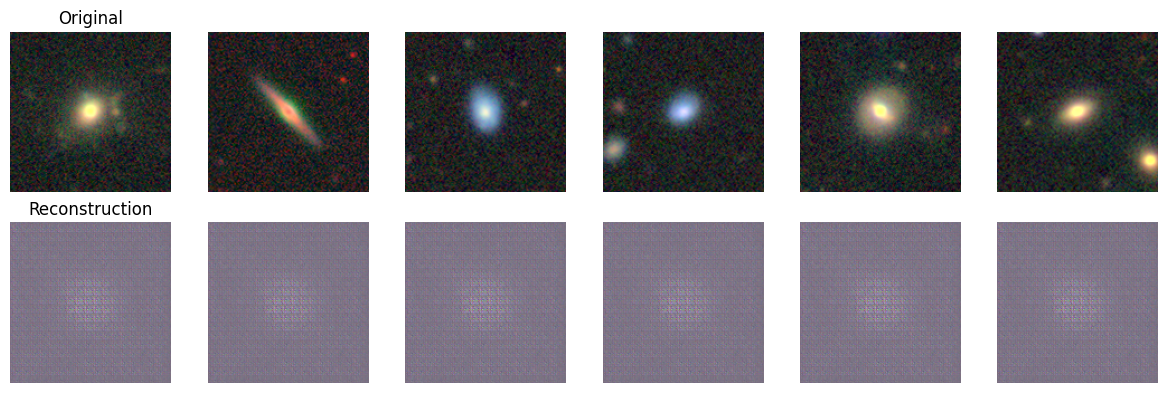

In [31]:
# Visualise image autoencoder reconstructions
image_model = image_model.to(device)
image_model.eval()

with torch.no_grad():
    images = next(iter(image_val_loader))
    inputs = images.to(device)
    recon = image_model(inputs).cpu()

n_show = min(6, inputs.size(0))
plt.figure(figsize=(12, 4))
for i in range(n_show):
    plt.subplot(2, n_show, i + 1)
    plt.imshow(images[i].permute(1, 2, 0).numpy())
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    plt.subplot(2, n_show, n_show + i + 1)
    plt.imshow(recon[i].permute(1, 2, 0).numpy())
    plt.axis("off")
    if i == 0:
        plt.title("Reconstruction")
plt.tight_layout()
plt.show()


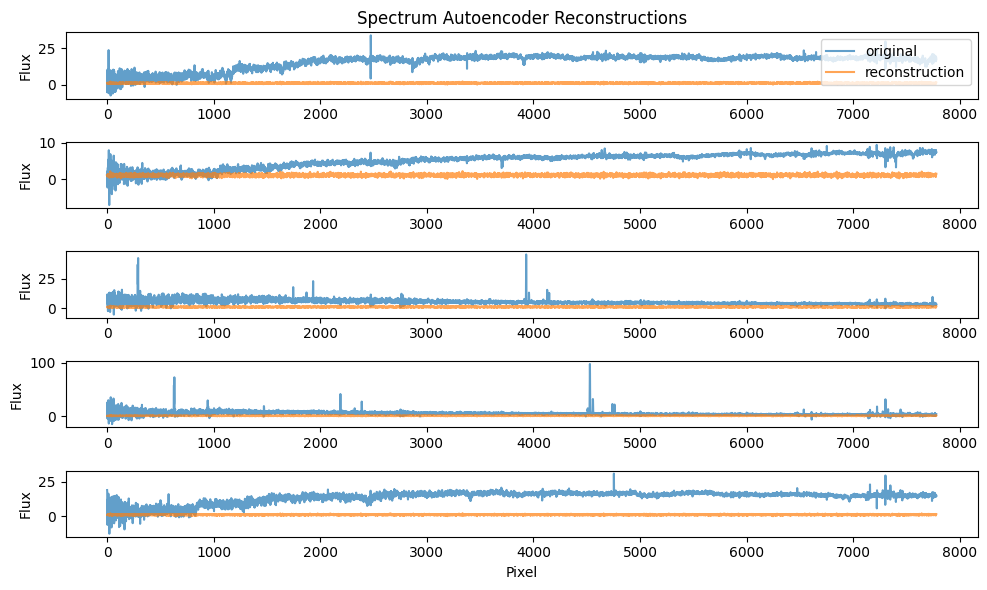

In [32]:
# Visualise spectrum autoencoder reconstructions
spectrum_model = spectrum_model.to(device)
spectrum_model.eval()

with torch.no_grad():
    spectra = next(iter(spectrum_val_loader))
    inputs = spectra.to(device)
    recon = spectrum_model(inputs).cpu()

n_show = min(5, inputs.size(0))
plt.figure(figsize=(10, 6))
for i in range(n_show):
    plt.subplot(n_show, 1, i + 1)
    plt.plot(spectra[i].numpy(), label="original", alpha=0.7)
    plt.plot(recon[i].numpy(), label="reconstruction", alpha=0.7)
    plt.ylabel("Flux")
    if i == 0:
        plt.title("Spectrum Autoencoder Reconstructions")
    if i == n_show - 1:
        plt.xlabel("Pixel")
    if i == 0:
        plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 2. CLIP Alignment & Embedding Exploration
Train/Load CLIP model and run UMAP.

In [25]:
class StudentCLIP(L.LightningModule):
    def __init__(self, image_encoder, spectrum_encoder, projection_dim=256, temperature=0.07, lr=5e-4, weight_decay=1e-5):
        super().__init__()
        self.save_hyperparameters(ignore=['image_encoder', 'spectrum_encoder'])
        self.image_encoder = image_encoder
        self.spectrum_encoder = spectrum_encoder
        self.img_proj = nn.Linear(getattr(image_encoder, 'embed_dim', projection_dim), projection_dim)
        self.spec_proj = nn.Linear(getattr(spectrum_encoder, 'embed_dim', projection_dim), projection_dim)
        self.temperature = temperature

    def encode_image(self, images):
        if hasattr(self.image_encoder, 'encode'):
            features = self.image_encoder.encode(images)
        else:
            features = self.image_encoder(images)
        projected = self.img_proj(features)
        return F.normalize(projected, dim=-1)

    def encode_spectrum(self, spectra):
        if hasattr(self.spectrum_encoder, 'encode'):
            features = self.spectrum_encoder.encode(spectra)
        else:
            features = self.spectrum_encoder(spectra)
        projected = self.spec_proj(features)
        return F.normalize(projected, dim=-1)

    def forward(self, images, spectra):
        img = self.encode_image(images)
        spec = self.encode_spectrum(spectra)
        return img, spec

    def training_step(self, batch, batch_idx):
        images, spectra = batch['image'], batch['spectrum']
        img, spec = self(images, spectra)
        logits = (img @ spec.T) / self.temperature
        targets = torch.arange(logits.size(0), device=logits.device)
        loss = (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, spectra = batch['image'], batch['spectrum']
        img, spec = self(images, spectra)
        logits = (img @ spec.T) / self.temperature
        targets = torch.arange(logits.size(0), device=logits.device)
        loss = (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2
        self.log('val_loss', loss, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
        return {'optimizer': optimizer, 'lr_scheduler': scheduler}


In [30]:
clip_ckpt_path = ASTROCLIP_ROOT / "models/clip_student.ckpt"
if clip_ckpt_path.exists():
    clip_model = StudentCLIP.load_from_checkpoint(clip_ckpt_path, image_encoder=image_model,spectrum_encoder=spectrum_model)
else:
    clip_model = StudentCLIP(image_encoder=image_model,spectrum_encoder=spectrum_model)
    clip_model = train_with_lightning(
    clip_model,
    clip_ckpt_path,
    multimodal_train_loader,
    multimodal_val_loader,
    max_epochs=1,
    logger_name="clip_ex",
    )

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Missing logger folder: /Users/marchuertascompany/Documents/teaching/2025_astroinfo/data/logs/clip_ex
/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:652: Checkpoint directory /Users/marchuertascompany/Documents/teaching/2025_astroinfo/data/models exists and is not empty.

  | Name             | Type                       | Params | Mode 
------------------------------------------------------------------------
0 | image_encoder    | StudentImageAutoencoder    | 43.0 M | eval 
1 | spectrum_encoder | StudentSpectrumAutoencoder | 17.3 M | train
2 | img_proj         | Linear                     | 65.8 K | train
3 | spec_proj        | Linear                     | 65.8 K | train
------------------------------------------------------------------------
60.4 M    Trainable params
0         Non-

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/marchuertascompany/soft

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


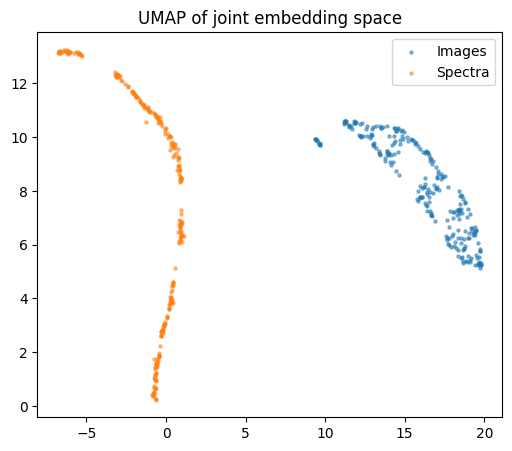

In [37]:
# Generate embeddings for the validation split and visualise with UMAP
image_embeddings, spectrum_embeddings, redshift = [], [], []

clip_model = clip_model.to(device)
clip_model.eval()
with torch.no_grad():
    for batch in multimodal_val_loader:
        imgs = batch["image"].to(device)
        specs = batch["spectrum"].to(device)
        img_embeds, spec_embeds = clip_model(imgs, specs)
        image_embeddings.append(img_embeds.cpu().numpy())
        spectrum_embeddings.append(spec_embeds.cpu().numpy())
        redshift.append(batch["redshift"].numpy())

image_embeddings = np.concatenate(image_embeddings)
spectrum_embeddings = np.concatenate(spectrum_embeddings)
redshift = np.concatenate(redshift)

reducer = umap.UMAP(random_state=42)
joint = reducer.fit_transform(np.concatenate([image_embeddings, spectrum_embeddings], axis=0))
labels = np.concatenate([np.zeros(len(image_embeddings)), np.ones(len(spectrum_embeddings))])

plt.figure(figsize=(6, 5))
plt.scatter(joint[labels == 0, 0], joint[labels == 0, 1], s=5, alpha=0.5, label="Images")
plt.scatter(joint[labels == 1, 0], joint[labels == 1, 1], s=5, alpha=0.5, label="Spectra")
plt.legend()
plt.title("UMAP of joint embedding space")
plt.show()


## 3. Regression Head
Use the embeddings to train a regression model.

Epoch 10: train=0.0192, val=0.0179
Epoch 20: train=0.0069, val=0.0062
Epoch 30: train=0.0072, val=0.0064
Epoch 40: train=0.0065, val=0.0058


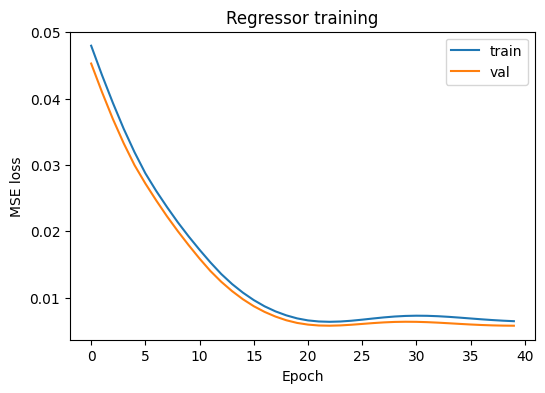

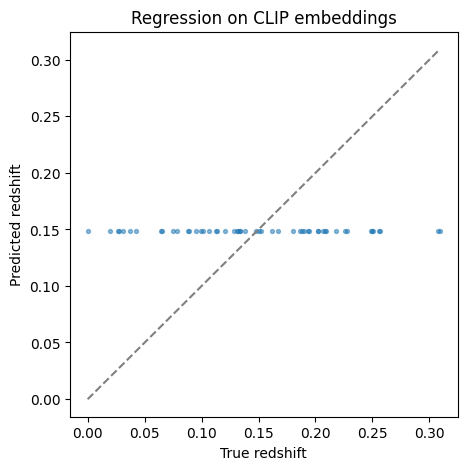

In [38]:
# Regression head on image embeddings
train_size = int(0.8 * len(image_embeddings))
train_emb = image_embeddings[:train_size]
val_emb = image_embeddings[train_size:]
train_z = redshift[:train_size]
val_z = redshift[train_size:]

train_ds = TensorDataset(torch.from_numpy(train_emb).float(), torch.from_numpy(train_z).float())
val_ds = TensorDataset(torch.from_numpy(val_emb).float(), torch.from_numpy(val_z).float())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=256, shuffle=False)

class StudentRegressor(torch.nn.Module):
    def __init__(self, input_dim, hidden=256):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)

def train_regressor(model, train_loader, val_loader, epochs=40):
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
    criterion = torch.nn.MSELoss()
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                running += loss.item() * xb.size(0)
        val_loss = running / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:02d}: train={train_loss:.4f}, val={val_loss:.4f}")

    return train_losses, val_losses

regressor = StudentRegressor(train_emb.shape[1]).to(device)
train_losses, val_losses = train_regressor(regressor, train_dl, val_dl, epochs=40)

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Regressor training')
plt.legend()
plt.show()

regressor.eval()
with torch.no_grad():
    val_inputs = torch.from_numpy(val_emb).float().to(device)
    preds_img = regressor(val_inputs).cpu().numpy()
true_img = val_z

plt.figure(figsize=(5, 5))
plt.scatter(true_img, preds_img, s=8, alpha=0.5)
lims = [true_img.min(), true_img.max()]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True redshift')
plt.ylabel('Predicted redshift')
plt.title('Regression on CLIP embeddings')
plt.show()


## 4. CNN Baseline
Train a CNN directly on images for comparison.

In [40]:
# Image-only CNN baseline
class ImageRedshiftDataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        record = dict(self.dataset[idx])
        image = torch.tensor(np.asarray(record["image"]), dtype=torch.float32).permute(2, 0, 1)
        redshift = torch.tensor(float(record["redshift"]), dtype=torch.float32)
        return image, redshift

cnn_train_dl = DataLoader(ImageRedshiftDataset(ds["train"]), batch_size=128, shuffle=True, num_workers=0)
cnn_val_dl   = DataLoader(ImageRedshiftDataset(ds["test"]),  batch_size=128, shuffle=False, num_workers=0)

class StudentImageCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.regressor(features).squeeze(-1)

def train_cnn(model, train_loader, val_loader, epochs=1):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = torch.nn.MSELoss()
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                running += loss.item() * xb.size(0)
        val_loss = running / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        tqdm.write(f"Epoch {epoch+1:02d}: train={train_loss:.4f}, val={val_loss:.4f}")

    return train_losses, val_losses

cnn_model = StudentImageCNN().to(device)
cnn_train_losses, cnn_val_losses = train_cnn(cnn_model, cnn_train_dl, cnn_val_dl, epochs=10)

plt.figure(figsize=(6, 4))
plt.plot(cnn_train_losses, label='train')
plt.plot(cnn_val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('CNN baseline training')
plt.legend()
plt.show()

cnn_model.eval()
cnn_preds, cnn_truth = [], []
with torch.no_grad():
    for xb, yb in cnn_val_dl:
        preds = cnn_model(xb.to(device)).cpu().numpy()
        cnn_preds.append(preds)
        cnn_truth.append(yb.numpy())
cnn_preds = np.concatenate(cnn_preds)
cnn_truth = np.concatenate(cnn_truth)


Epoch 1/10:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 01: train=0.0092, val=0.0073


Epoch 2/10:   0%|          | 0/8 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Compare Results
Plot predicted vs. true redshift for CLIP and baseline; discuss.

In [42]:
# Comparison cell
from sklearn.metrics import mean_squared_error, mean_absolute_error

clip_mse = mean_squared_error(true_img, preds_img)
clip_mae = mean_absolute_error(true_img, preds_img)
cnn_mse = mean_squared_error(cnn_truth, cnn_preds)
cnn_mae = mean_absolute_error(cnn_truth, cnn_preds)

print(f"CLIP embedding regressor MSE: {clip_mse:.4f}")
print(f"CLIP embedding regressor MAE: {clip_mae:.4f}")
print(f"CNN baseline MSE: {cnn_mse:.4f}")
print(f"CNN baseline MAE: {cnn_mae:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(true_img, preds_img, s=8, alpha=0.5)
lims = [true_img.min(), true_img.max()]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True redshift')
plt.ylabel('Predicted redshift')
plt.title('CLIP embedding regressor')

plt.subplot(1, 2, 2)
plt.scatter(cnn_truth, cnn_preds, s=8, alpha=0.5)
lims = [cnn_truth.min(), cnn_truth.max()]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True redshift')
plt.ylabel('Predicted redshift')
plt.title('Image CNN baseline')

plt.tight_layout()
plt.show()

if clip_mse < cnn_mse:
    conclusion = 'CLIP embeddings paired with a regressor perform better on this split.'
else:
    conclusion = 'The CNN baseline outperforms the CLIP-based regressor on this split.'
print(conclusion)


NameError: name 'cnn_truth' is not defined

## 8. Using the Official AstroCLIP Checkpoint

Load the published `astroclip.ckpt` checkpoint and run it over our dataset to obtain the reference image and spectrum embeddings.

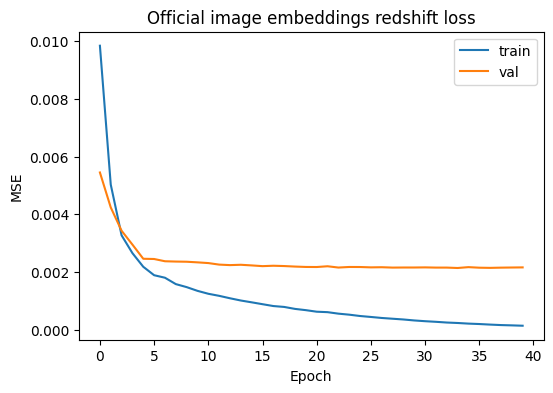

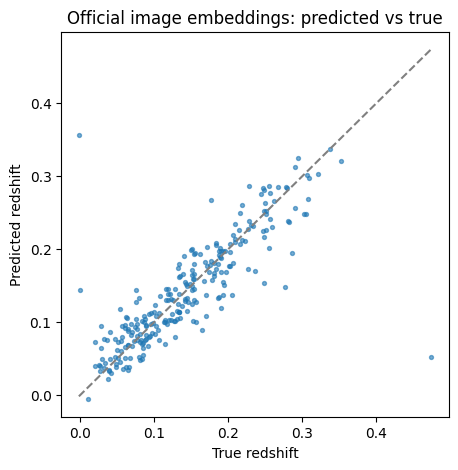

In [41]:
import h5py
from torch.utils.data import TensorDataset, DataLoader

# Adjust paths if you saved the files elsewhere
ROOT = Path("/Users/marchuertascompany/Documents/teaching/2025_astroinfo/data")
IMG_TRAIN_H5 = ROOT / "embeddings_image_train.h5"
IMG_TEST_H5  = ROOT / "embeddings_image_test.h5"

def load_split(path):
    with h5py.File(path, "r") as f:
        emb = f["image_embeddings"][:]
        z   = f["redshift"][:]
    return emb, z

train_emb, train_z = load_split(IMG_TRAIN_H5)
val_emb,   val_z   = load_split(IMG_TEST_H5)

train_ds = TensorDataset(torch.from_numpy(train_emb).float(), torch.from_numpy(train_z).float())
val_ds   = TensorDataset(torch.from_numpy(val_emb).float(),   torch.from_numpy(val_z).float())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=256, shuffle=False)

class MLP(torch.nn.Module):
    def __init__(self, input_dim, hidden=256):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

official_model = MLP(train_emb.shape[1]).to(device)          # MLP already defined above
optimizer = torch.optim.AdamW(official_model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = torch.nn.MSELoss()

official_train_losses, official_val_losses = [], []
for epoch in range(40):
    official_model.train()
    running = 0.0
    for x_batch, y_batch in train_dl:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        preds = official_model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        running += loss.item() * x_batch.size(0)
    train_loss = running / len(train_dl.dataset)

    official_model.eval()
    running = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_dl:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = official_model(x_batch)
            loss = criterion(preds, y_batch)
            running += loss.item() * x_batch.size(0)
    val_loss = running / len(val_dl.dataset)

    official_train_losses.append(train_loss)
    official_val_losses.append(val_loss)

plt.figure(figsize=(6, 4))
plt.plot(official_train_losses, label="train")
plt.plot(official_val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Official image embeddings redshift loss")
plt.legend()
plt.show()

official_model.eval()
official_preds = []
with torch.no_grad():
    for x_batch, _ in val_dl:
        official_preds.extend(official_model(x_batch.to(device)).cpu().numpy())
official_preds = np.array(official_preds)

plt.figure(figsize=(5, 5))
plt.scatter(val_z[: len(official_preds)], official_preds, s=8, alpha=0.6)
lims = [val_z.min(), val_z.max()]
plt.plot(lims, lims, "--", color="gray")
plt.xlabel("True redshift")
plt.ylabel("Predicted redshift")
plt.title("Official image embeddings: predicted vs true")
plt.show()
